# Sentiment CLassifier -fine turining BERT on Movie Reviews

## Required Libraries

In [ ]:
import torch
import numpy as np
import pandas as pd
from collections import Counter

from datasets import load_dataset #to access dataset from Hugging face datassets library
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix,ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import torch.nn.functional as F

### Loading the IMDB dataset

In [ ]:
dataset = load_dataset("stanfordnlp/imdb")

print(dataset)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


## Explore the Dataset

### Number of samples

In [ ]:
print("Train Size :", len(dataset["train"]))
print("Test Size :", len(dataset["test"]))
print("Unsupervised Size :", len(dataset["unsupervised"]))

Train Size : 25000
Test Size : 25000
Unsupervised Size : 50000


### Features in dataset

In [ ]:
dataset["train"].features

{'text': Value('string'), 'label': ClassLabel(names=['neg', 'pos'])}

### View Sample reviews

In [ ]:
print(dataset["train"][0]["text"])
print(dataset["train"][0]["label"])

I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such as the Vietnam War and race issues in the United States. In between asking politicians and ordinary denizens of Stockholm about their opinions on politics, she has sex with her drama teacher, classmates, and married men.<br /><br />What kills me about I AM CURIOUS-YELLOW is that 40 years ago, this was considered pornographic. Really, the sex and nudity scenes are few and far between, eve

### Label Mapping

In [ ]:
label_names = {
    0:"Negative",
    1:"Positive"
}

print(label_names[dataset["train"][0]["label"]])

Negative


### Display multiple examples

In [ ]:
for i in range(3):

    print(f"\nReview {i+1}")
    print("-"*60)

    print(dataset["train"][i]["text"][:500])

    print(
        "\nSentiment:",
        label_names[
            dataset["train"][i]["label"]
        ]
    )


Review 1
------------------------------------------------------------
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attent

Sentiment: Negative

Review 2
------------------------------------------------------------
"I Am Curious: Yellow" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim that frontal male nudity is an automatic NC-17, that isn't true. I've seen R-rated films with male nudity. Granted, they only offer some flee

### Class Distribution Analysis





Count Labels

In [ ]:
train_labels = dataset["train"]["label"]

pd.Series(train_labels).value_counts()

,count
0,12500
1,12500


Plot Distribution

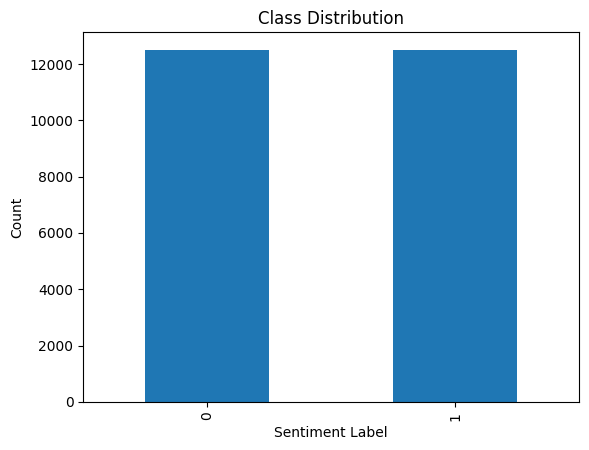

In [ ]:
pd.Series(train_labels).value_counts().plot(
    kind="bar"
)

plt.title("Class Distribution")
plt.xlabel("Sentiment Label")
plt.ylabel("Count")

plt.show()

Percentage Distribution

In [ ]:
label_counts = pd.Series(
    train_labels
).value_counts(normalize=True)*100

print(label_counts)

0    50.0
1    50.0
Name: proportion, dtype: float64


###Review Length Analysis

Calculate Lengths

In [ ]:
review_lengths = [
    len(review.split())
    for review in dataset["train"]["text"]
]

Basic Statistics

In [ ]:
print(
    "Average Length:",
    np.mean(review_lengths)
)

print(
    "Median Length:",
    np.median(review_lengths)
)

print(
    "Maximum Length:",
    np.max(review_lengths)
)

print(
    "Minimum Length:",
    np.min(review_lengths)
)

Average Length: 233.7872
Median Length: 174.0
Maximum Length: 2470
Minimum Length: 10


Length Distribution Histogram

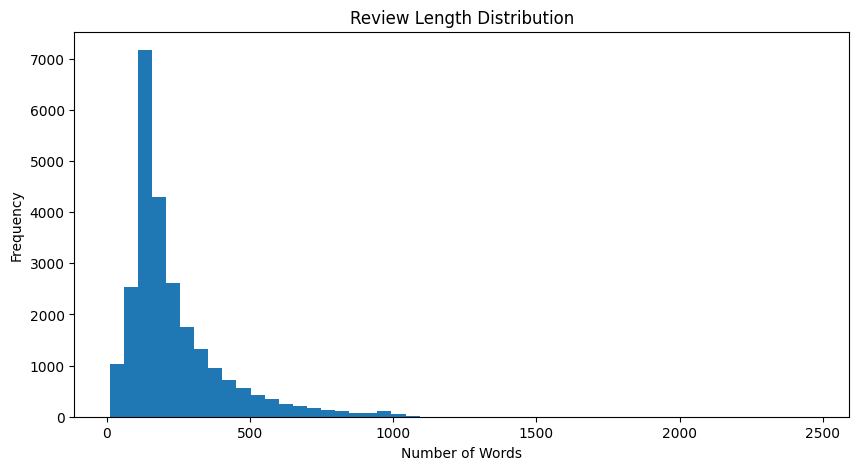

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    review_lengths,
    bins=50
)

plt.title(
    "Review Length Distribution"
)

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

Percentile Analysis

In [ ]:
print(
    "90th Percentile:",
    np.percentile(review_lengths,90)
)

print(
    "95th Percentile:",
    np.percentile(review_lengths,95)
)

print(
    "99th Percentile:",
    np.percentile(review_lengths,99)
)

90th Percentile: 458.0
95th Percentile: 598.0
99th Percentile: 913.0


### Vocabulary Analysis

Build Vocabulary

In [ ]:
all_words = []

for review in dataset["train"]["text"][:5000]:

    words = review.lower().split()

    all_words.extend(words)

Count Vocabulary

In [ ]:
vocab = Counter(all_words)

print(
    "Vocabulary Size:",
    len(vocab)
)

Vocabulary Size: 88254


Most Common Words

In [ ]:
vocab.most_common(20)

[('the', 62005),
 ('a', 31313),
 ('and', 28617),
 ('of', 27433),
 ('to', 27015),
 ('is', 19265),
 ('in', 16931),
 ('this', 14997),
 ('i', 14978),
 ('that', 13392),
 ('it', 12952),
 ('/><br', 10579),
 ('was', 10228),
 ('for', 8532),
 ('but', 8070),
 ('with', 7964),
 ('as', 7961),
 ('movie', 6860),
 ('on', 6252),
 ('not', 6028)]

Convert to Dataframe

In [ ]:
top_words = pd.DataFrame(
    vocab.most_common(20),
    columns=["Word","Frequency"]
)

top_words

,Word,Frequency
0,the,62005
1,a,31313
2,and,28617
3,of,27433
4,to,27015
5,is,19265
6,in,16931
7,this,14997
8,i,14978
9,that,13392


Visualise the most frequent words

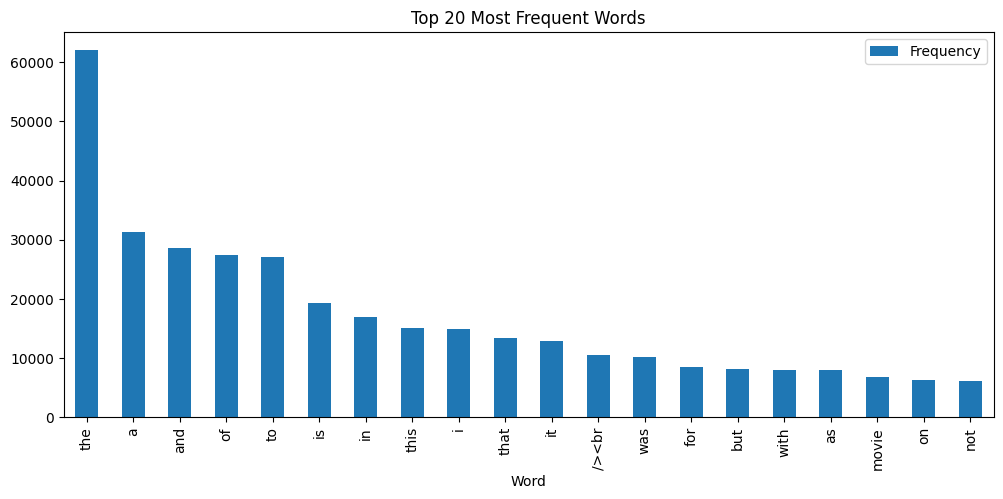

In [ ]:
top_words.plot(
    x="Word",
    y="Frequency",
    kind="bar",
    figsize=(12,5)
)

plt.title(
    "Top 20 Most Frequent Words"
)

plt.show()

### Review Length Categories

Most useful analysis for this report

In [ ]:
short_reviews = 0
medium_reviews = 0
long_reviews = 0

for length in review_lengths:

    if length < 100:
        short_reviews += 1

    elif length < 300:
        medium_reviews += 1

    else:
        long_reviews += 1

Display Counts

In [ ]:
print("Short Reviews :", short_reviews)
print("Medium Reviews :", medium_reviews)
print("Long Reviews :", long_reviews)

Short Reviews : 2926
Medium Reviews : 16319
Long Reviews : 5755


Pie Chart Visualisation

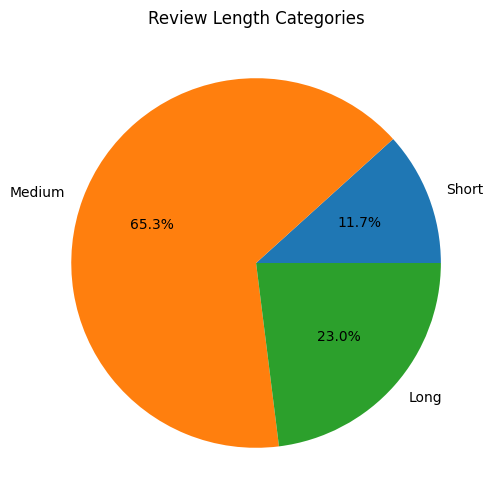

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    [short_reviews,
     medium_reviews,
     long_reviews],

    labels=[
        "Short",
        "Medium",
        "Long"
    ],

    autopct="%1.1f%%"
)

plt.title(
    "Review Length Categories"
)

plt.show()

## Tokenization

### Load BERT tokenizer

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "bert-base-uncased"
)

### Tokenize a sample review

Inspect what BERT receives as input

In [ ]:
sample_text = dataset["train"][0]["text"]

encoded_sample = tokenizer(sample_text)

print(encoded_sample.keys())

KeysView({'input_ids': [101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036, 2657, 2008, 2012, 2034, 2009, 2001, 8243, 2011, 1057, 1012, 1055, 1012, 8205, 2065, 2009, 2412, 2699, 2000, 4607, 2023, 2406, 1010, 3568, 2108, 1037, 5470, 1997, 3152, 2641, 1000, 6801, 1000, 1045, 2428, 2018, 2000, 2156, 2023, 2005, 2870, 1012, 1026, 7987, 1013, 1028, 1026, 7987, 1013, 1028, 1996, 5436, 2003, 8857, 2105, 1037, 2402, 4467, 3689, 3076, 2315, 14229, 2040, 4122, 2000, 4553, 2673, 2016, 2064, 2055, 2166, 1012, 1999, 3327, 2016, 4122, 2000, 3579, 2014, 3086, 2015, 2000, 2437, 2070, 4066, 1997, 4516, 2006, 2054, 1996, 2779, 25430, 14728, 2245, 2055, 3056, 2576, 3314, 2107, 2004, 1996, 5148, 2162, 1998, 2679, 3314, 1999, 1996, 2142, 2163, 1012, 1999, 2090, 4851, 8801, 1998, 6623, 7939, 4697, 3619, 1997, 8947, 2055, 2037, 10740, 2006, 4331, 1010, 2016, 2038, 3348, 2007, 2014, 

### Understanding BERT inputs

Input IDs

In [ ]:
print(encoded_sample["input_ids"][:30])

[101, 1045, 12524, 1045, 2572, 8025, 1011, 3756, 2013, 2026, 2678, 3573, 2138, 1997, 2035, 1996, 6704, 2008, 5129, 2009, 2043, 2009, 2001, 2034, 2207, 1999, 3476, 1012, 1045, 2036]


Attention Mask

In [ ]:
print(encoded_sample["attention_mask"][:30])

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Token type IDs

In [ ]:
print(encoded_sample["token_type_ids"][:30])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


###Convert Tokens back to words

In [ ]:
tokens = tokenizer.convert_ids_to_tokens(
    encoded_sample["input_ids"][:30]
)

print(tokens)

['[CLS]', 'i', 'rented', 'i', 'am', 'curious', '-', 'yellow', 'from', 'my', 'video', 'store', 'because', 'of', 'all', 'the', 'controversy', 'that', 'surrounded', 'it', 'when', 'it', 'was', 'first', 'released', 'in', '1967', '.', 'i', 'also']


### Tokenize entire Dataset

Create Tokenization function

In [ ]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=256
    )

Apply Tokenization

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

### Remove Raw Text

In [ ]:
tokenized_dataset = tokenized_dataset.remove_columns(
    ["text"]
)

###Set Pytorch Format and verify

In [ ]:
tokenized_dataset.set_format(
    "torch"
)

## Fine-Tuning BERT

###Load Pretrained BERT Model

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


### Create Metrics Function

In [ ]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(
        logits,
        axis=-1
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    f1 = f1_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

### Training Arguments
for GPU

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=8,

    per_device_eval_batch_size=8,

    num_train_epochs=2,

    weight_decay=0.01,

    logging_steps=100,

    load_best_model_at_end=True,

    report_to="none"
)

###Create Trainer

In [ ]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=tokenized_dataset["train"],

    eval_dataset=tokenized_dataset["test"],

    compute_metrics=compute_metrics
)

### Train BERT

In [ ]:
import datasets
datasets.config.TORCHVISION_AVAILABLE = False
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.268614,0.258309,0.913760,0.910725
2,0.159208,0.329179,0.923760,0.924401


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=6250, training_loss=0.24980715621948243, metrics={'train_runtime': 3067.823, 'train_samples_per_second': 16.298, 'train_steps_per_second': 2.037, 'total_flos': 6577776384000000.0, 'train_loss': 0.24980715621948243, 'epoch': 2.0})

## Evaluation

### Evaluate Model

In [ ]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.159208,0.258434,2,0.913880,0.910875


{'eval_loss': 0.2584337890148163, 'eval_accuracy': 0.91388, 'eval_f1': 0.9108746947054684}


### Generate Predictions

In [ ]:
predictions = trainer.predict(
    tokenized_dataset["test"]
)

### Predicted Labels

In [ ]:
predicted_labels = np.argmax(
    predictions.predictions,
    axis=1
)

true_labels = predictions.label_ids

### Confusion Matrix

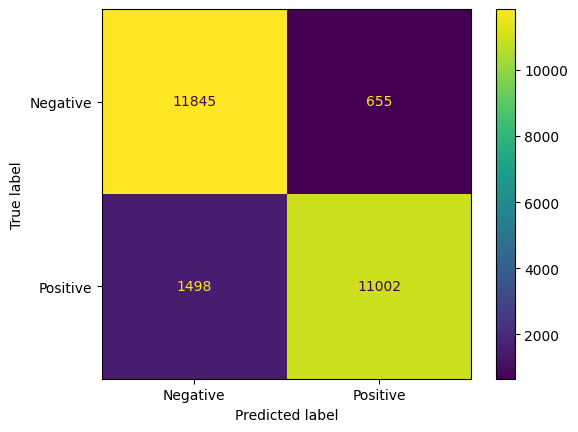

In [ ]:
cm = confusion_matrix(
    true_labels,
    predicted_labels
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Negative",
        "Positive"
    ]
)

disp.plot()

plt.show()

### Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        predicted_labels,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)

              precision    recall  f1-score   support

    Negative       0.89      0.95      0.92     12500
    Positive       0.94      0.88      0.91     12500

    accuracy                           0.91     25000
   macro avg       0.92      0.91      0.91     25000
weighted avg       0.92      0.91      0.91     25000



### Test Custom Reviews

In [ ]:
custom_reviews = [

    "This movie was absolutely fantastic.",

    "The film was boring and too long.",

    "Amazing acting and excellent story.",

    "I hated every minute of it.",

    "One of the worst movies ever made."
]
for review in custom_reviews:

    inputs = tokenizer(
        review,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    # Move inputs to the same device as the model
    inputs = {key: val.to(model.device) for key, val in inputs.items()}

    outputs = model(**inputs)

    prediction = torch.argmax(
        outputs.logits,
        dim=1
    ).item()

    label = (
        "Positive"
        if prediction == 1
        else "Negative"
    )

    print(
        f"{review}\nPrediction: {label}\n"
    )

This movie was absolutely fantastic.
Prediction: Positive

The film was boring and too long.
Prediction: Negative

Amazing acting and excellent story.
Prediction: Positive

I hated every minute of it.
Prediction: Negative

One of the worst movies ever made.
Prediction: Negative



## Inference Functions

In [ ]:
def predict(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    with torch.no_grad():

        outputs = model(**inputs)

    probabilities = F.softmax(
        outputs.logits,
        dim=1
    )

    confidence, prediction = torch.max(
        probabilities,
        dim=1
    )

    sentiment = (
        "Positive"
        if prediction.item() == 1
        else "Negative"
    )

    return {
        "sentiment": sentiment,
        "confidence": round(
            confidence.item()*100,
            2
        )
    }